In [2]:
import pandas as pd
import  numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("homeprices.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


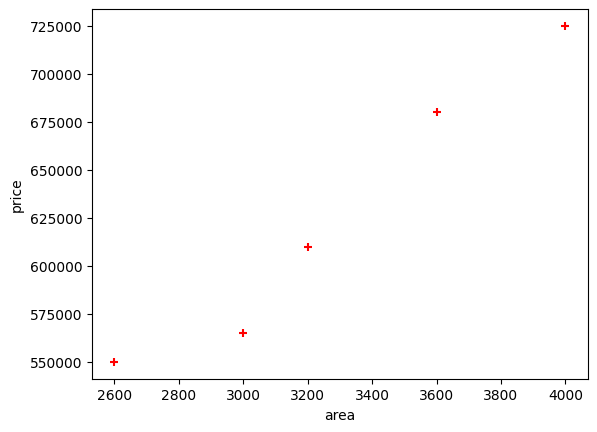

In [4]:
plt.xlabel("area")
plt.ylabel("price")
plt.scatter(df.area,df.price,color = "red",marker = "+")

In [5]:
area = df.drop("price",axis = "columns")
area

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [6]:
price = df.price
price

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [7]:
#eqn for linear reg y = mx + c
reg = linear_model.LinearRegression()
reg.fit(area,price)

LinearRegression()

In [8]:
reg.coef_

array([135.78767123])

In [9]:
reg.intercept_

180616.43835616432

In [19]:
#to predict the new area 3500
#reg.predict([[3500]])
new_data = pd.DataFrame([[3500]],columns = ['area'])
prediction = reg.predict(new_data)
prediction = np.round(prediction,2)
prediction

array([655873.29])

In [20]:
135.78767123*3500 + 180616.43835616432

655873.2876611643

In [21]:
p = reg.predict(df[['area']])
p = np.round(p,2)
p

array([533664.38, 587979.45, 615136.99, 669452.05, 723767.12])

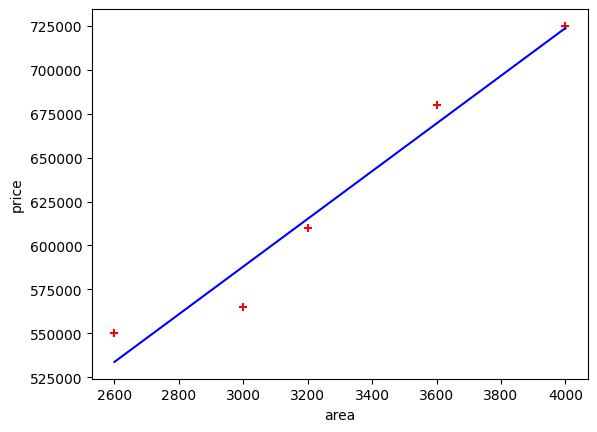

In [22]:
plt.xlabel("area")
plt.ylabel("price")
plt.scatter(df.area,df.price,color = "red",marker = "+")
plt.plot(df.area,reg.predict(df[['area']]),color = "blue")

In [23]:
reg.score(df[['area']],df.price)

0.9584301138199486

In [24]:
new_data = pd.DataFrame([[6500]],columns = ['area'])
prediction = reg.predict(new_data)
prediction = np.round(prediction,2)
prediction

array([1063236.3])

In [25]:
new_data = pd.DataFrame([[10000]],columns = ['area'])
prediction = reg.predict(new_data)
prediction = np.round(prediction,2)
prediction

array([1538493.15])

In [27]:
d = pd.read_csv("areas.csv")
d.head()

,area
0,1000
1,1500
2,2300
3,3540
4,4120


In [29]:
pred = reg.predict(d)
pred = np.round(pred,2)
pred 

array([ 316404.11,  384297.95,  492928.08,  661304.79,  740061.64,
        799808.22,  926090.75,  650441.78,  825607.88,  492928.08,
       1402705.48, 1348390.41, 1144708.9 ])

In [31]:
d['predicted_price'] = pred

In [32]:
d

,area,predicted_price
0,1000,316404.11
1,1500,384297.95
2,2300,492928.08
3,3540,661304.79
4,4120,740061.64
5,4560,799808.22
6,5490,926090.75
7,3460,650441.78
8,4750,825607.88
9,2300,492928.08


In [34]:
d.to_csv("predicted_price.csv",index = False)

In [35]:
reg.score(d[['area']],d.predicted_price)

0.9999999999999999

   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583
Predicted per capita income in 2020: 41288.69409441762


C:\Users\sumai\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


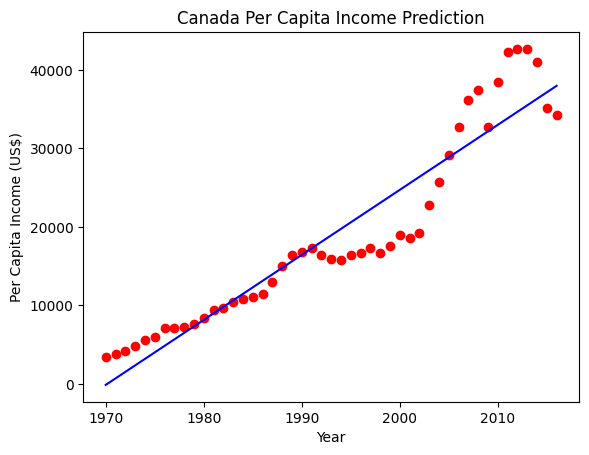

In [36]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Step 2: Load dataset
df = pd.read_csv("canada_per_capita_income.csv")

# Step 3: Display first few rows
print(df.head())

# Step 4: Prepare data
X = df[['year']]   # independent variable
y = df['per capita income (US$)']   # dependent variable

# Step 5: Create and train model
model = LinearRegression()
model.fit(X, y)

# Step 6: Predict income for 2020
prediction_2020 = model.predict([[2020]])

print("Predicted per capita income in 2020:", prediction_2020[0])

# Step 7: Plot regression line
plt.scatter(X, y, color='red')
plt.plot(X, model.predict(X), color='blue')
plt.xlabel("Year")
plt.ylabel("Per Capita Income (US$)")
plt.title("Canada Per Capita Income Prediction")
plt.show()

In [76]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

df = pd.read_csv("hiring.csv")

# Clean experience column
df['experience'] = df['experience'].astype(str).str.strip().str.lower()

word_to_num = {
    'zero':0, 'one':1, 'two':2, 'three':3, 'four':4,
    'five':5, 'six':6, 'seven':7, 'eight':8,
    'nine':9, 'ten':10, 'eleven':11, 'twelve':12
}

# Replace only word values
df['experience'] = df['experience'].replace(word_to_num)

# Convert everything to numeric
df['experience'] = pd.to_numeric(df['experience'], errors='coerce')

# Fill missing
df['experience'] = df['experience'].fillna(0)

# Fix test score
df['test_score(out of 10)'] = pd.to_numeric(
    df['test_score(out of 10)'], errors='coerce'
)

df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(
    df['test_score(out of 10)'].median()
)

# Define X and y
X = df[['experience','test_score(out of 10)','interview_score(out of 10)']]
y = df['salary($)']

model = LinearRegression()
model.fit(X,y)

# Predict properly
candidate1 = pd.DataFrame([[2,9,6]], columns=X.columns)
candidate2 = pd.DataFrame([[12,10,10]], columns=X.columns)

print("2 yr, 9 test, 6 interview:", model.predict(candidate1))
print("12 yr, 10 test, 10 interview:", model.predict(candidate2))

2 yr, 9 test, 6 interview: [53205.96797671]
12 yr, 10 test, 10 interview: [92002.18340611]
